In [240]:
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
df=pd.read_csv("Bengaluru_House_Data.csv") 
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [241]:
#checking and removing the unwanted columns , area_type, society, balcony, availability are not required for our analysis or axis=1 which means it ensures that it will executing column by column and not row by row

df.drop(['area_type','society','balcony','availability'],axis=1,inplace=True)
df.head()


,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [242]:
df.isnull().sum() 

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [243]:
#handle missing values in location column
df['location'].value_counts()#count of houses in whitefield and sarjapur road more
df["location"]=df["location"].fillna("Sarjapur Road")
df["location"].value_counts()


location
Whitefield                                         540
Sarjapur  Road                                     399
Electronic City                                    302
Kanakpura Road                                     273
Thanisandra                                        234
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1306, dtype: int64

In [244]:
df['size'].value_counts()
df["size"]=df["size"].fillna("2 BHK")
df['size'].value_counts()



size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [245]:
#handling nan values in bath columns
med_bath=df["bath"].median()
med_bath
df["bath"]=df["bath"].fillna(med_bath)
#since mean value gave floating point number

In [246]:
df["bath"]=df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [247]:
#drop duplicate rows
df.drop_duplicates(inplace=True)

In [248]:
df["location"].value_counts() #checking for outliers or inconsistent values or 

location
Whitefield                                         507
Sarjapur  Road                                     364
Electronic City                                    273
Thanisandra                                        224
Kanakpura Road                                     223
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1306, dtype: int64

In [249]:
df["location"]=df["location"].apply(lambda x:x.strip()) #.apply is used to map a single funct

loc=df["location"].value_counts()
loc_lthan_10=loc[loc <= 10]

df["location"]=df["location"].apply(lambda x:"others" if x in loc_lthan_10 else x)
df["location"].value_counts()

location
others                  2928
Whitefield               508
Sarjapur  Road           364
Electronic City          275
Thanisandra              226
                        ... 
NGR Layout                11
Doddakallasandra          11
Banashankari Stage V      11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [250]:
df['size'].value_counts() #checking for outliers or inconsistent values or

out=[int(i.split()[0]) for i in df['size']]

df['bhk']=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [251]:
#handling total_sqft column
#since it has same object type vlaues like ranges , 10 we need convert that into numeric
#this func  is about splitting those range type values , and


def clean_sqft(sqft):
    li=sqft.split("-")
    try:
        if len(li)==2:
            return (float(li[0]) + float(li[1]))/2
        else:
            return float(li[0])
    except: 
        return None

df['total_sqft']=df['total_sqft'].apply(clean_sqft)
df["total_sqft"]=df["total_sqft"].fillna(round(df["total_sqft"].mean()))

In [252]:
#create price_per_sqft column
#formula : price_per_sqft = (price*100000)/total_sqft

df["price_per_sqft"]=df["price"]*100000/df["total_sqft"]
df 

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [253]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12438.000000,12438.000000,12438.000000,12438.000000,1.243800e+04
mean,1576.375455,2.715549,115.408159,2.826821,8.103969e+03
std,1271.473866,1.367021,153.069125,1.323065,1.099449e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.306516e+03
50%,1290.000000,2.000000,74.000000,3.000000,5.500000e+03
75%,1697.750000,3.000000,125.000000,3.000000,7.460272e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [254]:
df=df[df["total_sqft"]/df["bhk"]>=300] #removing outliers where sqft per bhk is less than 300
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [255]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1614.029039,2.579667,114.455648,2.666809,6405.091922
std,1296.481391,1.099383,156.421987,0.995743,4281.960473
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1120.000000,2.000000,50.000000,2.000000,4253.521127
50%,1314.000000,2.000000,71.000000,3.000000,5348.837209
75%,1720.000000,3.000000,120.000000,3.000000,7000.000000
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [256]:
#handling outliers in one
df=df[df["bhk"]<=6] # keeping only the bhk where the value is 6

In [257]:
#handling outliers in bath column
# bhk+2 - beacuse we can have at max 2 bath rooms more than the number of bhk
df=df[df["bath"]<df["bhk"]+2]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


<Axes: xlabel='price_per_sqft'>

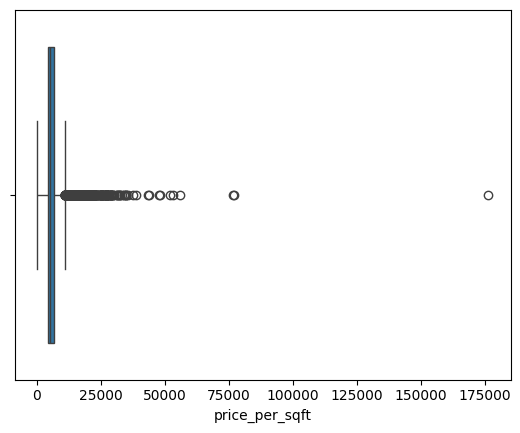

In [258]:
#handling outliers in price per sqft
sns.boxplot(x="price_per_sqft",data=df)

<Axes: xlabel='price_per_sqft'>

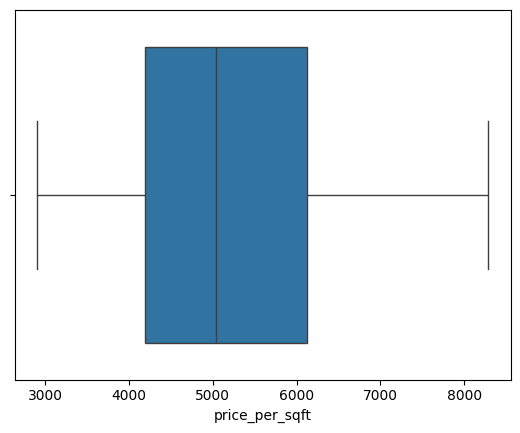

In [259]:
#IQR method
q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)

IQR=q3-q1

lower=q1-0.5*IQR
upper=q3+0.5*IQR

df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)

In [260]:
#after all the cleaning , our index values has been jumbled up so we need to reset the index values
df.reset_index(inplace=True)
df

,index,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...
9356,13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9357,13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9358,13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9359,13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [261]:
#now , after all the cleaning, we can reomove  the price_per_sqft  which was only 
df=df.drop(["index","size"],axis=1)
df

,location,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3,95.00,3,6245.890861
4,Kothanur,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...
9356,Rachenahalli,1050.0,2,52.71,2,5020.000000
9357,Bellandur,1262.0,2,47.00,2,3724.247227
9358,Green Glen Layout,1715.0,3,112.00,3,6530.612245
9359,Whitefield,3453.0,4,231.00,5,6689.834926


In [262]:
df=pd.get_dummies(df,columns=["location"],drop_first=True,dtype=int)

In [263]:
df.columns

Index(['total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft',
       'location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi',
       'location_5th Block Hbr Layout', 'location_5th Phase JP Nagar',
       'location_6th Phase JP Nagar',
       ...
       'location_Vishveshwarya Layout', 'location_Vishwapriya Layout',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_others'],
      dtype='str', length=235)

In [264]:
scaler = StandardScaler()
x_scaled=scaler.fit_transform(df)

In [265]:
X=df.drop(["price","price_per_sqft"],axis=1) #location because object type and price_per_sqft because it is only used for outlier detection and not required for model training
y=df.price

In [266]:
from sklearn.model_selection import train_test_split

In [267]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

In [268]:
from sklearn.ensemble import RandomForestRegressor

In [269]:
from sklearn.model_selection import GridSearchCV

In [270]:
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200],
    "max_depth":[3,4,5,6,7]
}
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(Xtrain,ytrain)
print("Best params:",grid.best_params_)
print("Best Score:",grid.best_score_)

Best params: {'max_depth': 7, 'n_estimators': 200}
Best Score: 0.8427210999677612


In [271]:
df.shape


(9361, 235)

In [272]:
#model training with best estimators
best_model=grid.best_estimator_

In [273]:
ypred=grid.predict(Xtest)
ypred

array([81.31687574, 60.33755385, 69.19455582, ..., 71.10576544,
       60.37809717, 63.05690767], shape=(2809,))

In [274]:
print("Training eff:",grid.score(Xtrain,ytrain))
print("Testing eff:",grid.score(Xtest,ytest))

Training eff: 0.9062521949302164
Testing eff: 0.8117090652406536


In [275]:
df.shape

(9361, 235)

In [276]:
from sklearn.metrics import r2_score,mean_absolute_error

In [277]:

print('R2:',r2_score(ytest,ypred))
print('MAE:',mean_absolute_error(ytest,ypred))

R2: 0.8117090652406536
MAE: 14.098159271847013


In [278]:
#save the cleaned dataset

df.to_csv("cleaned_df.csv")



In [279]:
import joblib
joblib.dump(best_model,'rf_model.joblib')

['rf_model.joblib']

In [280]:
joblib.dump(Xtrain.columns.tolist(),'model_columns.joblib')

['model_columns.joblib']